# Module 3 · Is the difference real?

**Module 3 of the spiral:** the drill-down claim — *in Bing, partner B beats A on EPC* — is a two-group difference. Pick the right test for the shape, respect the n-trap, and check for a confound (Simpson's). *Synthetic teaching dataset.*

# Module 4 — Is the Difference Real? Hypothesis Testing
### Practical Statistics for Analysts @ Natural Intelligence

Back to the Slack message: **Google 45% vs Bing 35% conversion.** Real, or noise?
Hypothesis testing is the discipline of asking *"if there were truly no difference,
how surprising is what I see?"* — the **p-value**. We'll also meet the traps that
make analysts over-claim: **sample size, the wrong test for skewed data, power,
and multiple comparisons.**

In [1]:
import sys
from pathlib import Path
_here = Path.cwd()
for _c in [_here, *_here.parents]:
    if (_c / "src" / "ni_style.py").exists():
        sys.path.insert(0, str(_c / "src")); break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ni_style as ni
ni.set_style()

visits = ni.load_visits()
print(f"Loaded {len(visits):,} visits | {visits['date'].min().date()} -> {visits['date'].max().date()}")
visits.head()

Loaded 180,000 visits | 2026-03-01 -> 2026-05-30


,visit_id,date,day_of_week,is_weekend,engine,device,vertical,converted,revenue,cost,profit
0,1,2026-03-01,Sun,True,Bing,mobile,vpn,0,0.0000,0.8094,-0.8094
1,2,2026-03-01,Sun,True,Organic,tablet,vpn,0,0.0000,0.1886,-0.1886
2,3,2026-03-01,Sun,True,Google,tablet,web_builders,0,0.0000,3.6039,-3.6039
3,4,2026-03-01,Sun,True,Google,desktop,dating,1,10.0945,1.0836,9.0109
4,5,2026-03-01,Sun,True,Google,desktop,streaming,1,5.6453,0.8228,4.8225


## 1. Two-proportion test: Google vs Bing conversion

- **H₀ (null):** Google and Bing convert at the same rate.
- **H₁:** they differ.

A tiny p-value means *"this gap would be very unlikely if H₀ were true."*

Google: 44.3%  (n=90,134)
Bing  : 34.5%  (n=32,127)
difference = +9.7%   z = 30.4   p-value = 0.00e+00


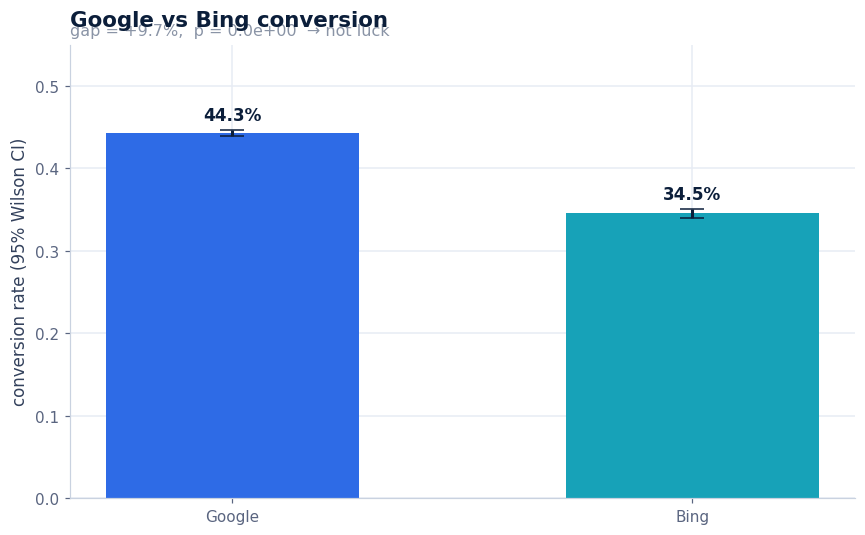

In [2]:
g = visits[visits.engine.isin(["Google","Bing"])].groupby("engine", observed=True)["converted"].agg(["sum","size"])
kG, nG = g.loc["Google"]; kB, nB = g.loc["Bing"]
res = ni.two_proportion_ztest(int(kG), int(nG), int(kB), int(nB))
print(f"Google: {res['p1']:.1%}  (n={nG:,})")
print(f"Bing  : {res['p2']:.1%}  (n={nB:,})")
print(f"difference = {res['diff']:+.1%}   z = {res['z']:.1f}   p-value = {res['p_value']:.2e}")

fig, ax = plt.subplots(figsize=(8, 5))
for i, eng in enumerate(["Google","Bing"]):
    k, n = (kG,nG) if eng=="Google" else (kB,nB)
    p, lo, hi = ni.wilson_ci(int(k), int(n))
    ax.bar(i, p, 0.55, color=ni.ENGINE_COLORS[eng])
    ax.errorbar(i, p, yerr=[[p-lo],[hi-p]], color=ni.NAVY, capsize=8, lw=2)
    ax.text(i, hi+0.012, f"{p:.1%}", ha="center", fontweight="bold", color=ni.NAVY)
ax.set_xticks([0,1]); ax.set_xticklabels(["Google","Bing"]); ax.set_ylim(0, 0.55)
ax.set_ylabel("conversion rate (95% Wilson CI)")
ni.titlebox(ax, "Google vs Bing conversion", f"gap = {res['diff']:+.1%},  p = {res['p_value']:.1e}  → not luck")
fig.tight_layout(); ni.savefig(fig, "m4_google_vs_bing"); plt.show()

## 2. The #1 trap: significance depends on sample size

The **same 10-point gap** is "insignificant" at small n and "rock-solid" at large n.
A p-value is not an effect size — it's a statement about *evidence*, which grows with data.
Left: p-value shrinks as we feed in more visits. Right: an **A/A test** (no real
difference) produces p-values scattered everywhere — most "findings" at small n are noise.

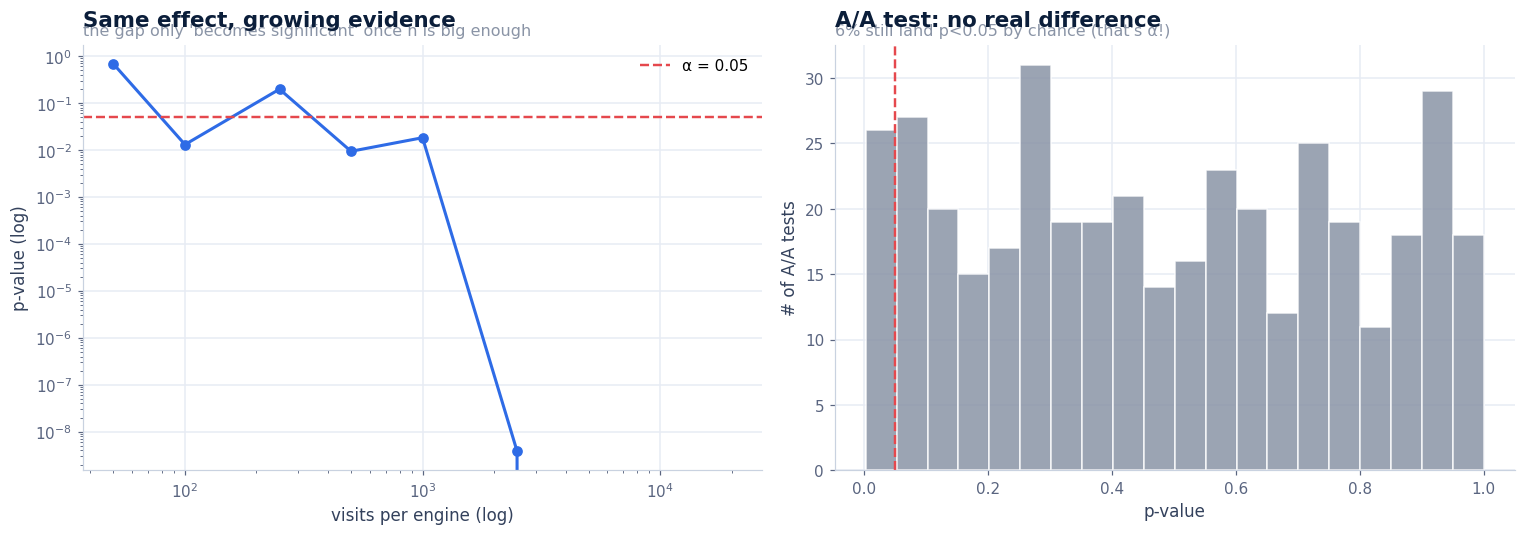

In [3]:
rng = np.random.default_rng(0)
G = visits[visits.engine=="Google"]["converted"].values
B = visits[visits.engine=="Bing"]["converted"].values

sizes = [50, 100, 250, 500, 1000, 2500, 5000, 10000, 20000]
pvals = []
for nps in sizes:
    gk = rng.choice(G, nps); bk = rng.choice(B, nps)
    pvals.append(ni.two_proportion_ztest(gk.sum(), nps, bk.sum(), nps)["p_value"])

# A/A null: split Google against itself, repeat
aa = []
for _ in range(400):
    idx = rng.permutation(len(G)); half = len(G)//2
    a, b = G[idx[:half]], G[idx[half:2*half]]
    aa.append(ni.two_proportion_ztest(a.sum(), len(a), b.sum(), len(b))["p_value"])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(sizes, pvals, "-o", color=ni.BLUE, lw=2)
ax[0].axhline(0.05, color=ni.RED, ls="--", lw=1.6, label="α = 0.05")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("visits per engine (log)"); ax[0].set_ylabel("p-value (log)"); ax[0].legend()
ni.titlebox(ax[0], "Same effect, growing evidence", "the gap only 'becomes significant' once n is big enough")

ax[1].hist(aa, bins=20, color=ni.GREY, alpha=0.85, edgecolor="white")
ax[1].axvline(0.05, color=ni.RED, ls="--", lw=1.6)
fp = np.mean(np.array(aa) < 0.05)
ax[1].set_xlabel("p-value"); ax[1].set_ylabel("# of A/A tests")
ni.titlebox(ax[1], "A/A test: no real difference", f"{fp:.0%} still land p<0.05 by chance (that's α!)")
fig.tight_layout(); ni.savefig(fig, "m4_sample_size"); plt.show()

## 3. The right test for *skewed* EPV: t-test vs Mann-Whitney

For mobile-vs-desktop **EPV** the outcome is heavy-tailed, so a plain t-test on the
mean is shaky. Compare it with the **Mann-Whitney** rank test and a **bootstrap** —
when they agree, you can trust the call; when they disagree, the whales are talking.

In [4]:
mob = visits[visits.device=="mobile"]["revenue"].values
desk = visits[visits.device=="desktop"]["revenue"].values

t = stats.ttest_ind(mob, desk, equal_var=False)
u = stats.mannwhitneyu(mob, desk, alternative="two-sided")
point, lo, hi, _ = ni.bootstrap_ratio_ci(mob, desk, n_boot=3000, seed=3)
print(f"Welch t-test     : t={t.statistic:.1f},  p={t.pvalue:.2e}")
print(f"Mann-Whitney U   : p={u.pvalue:.2e}   (rank-based, robust to whales)")
print(f"Bootstrap EPV gap: {point:+.1f}%   95% CI [{lo:+.1f}%, {hi:+.1f}%]")
print("→ All three agree mobile EPV is genuinely lower. Confidence is high.")

Welch t-test     : t=-4.9,  p=8.74e-07
Mann-Whitney U   : p=2.31e-14   (rank-based, robust to whales)
Bootstrap EPV gap: -10.3%   95% CI [-13.9%, -6.4%]
→ All three agree mobile EPV is genuinely lower. Confidence is high.


## 4. Chi-square: are engine and device *associated*?

When both variables are categorical (engine × device, outcome = converted),
the **chi-square test** asks whether the pattern of conversions is independent of
the combination — useful before you trust a per-cell number.

In [5]:
ct = pd.crosstab(visits.engine, visits.device, values=visits.converted, aggfunc="sum")
nt = pd.crosstab(visits.engine, visits.device)
chi2, p, dof, _ = stats.chi2_contingency(ct.values)
print("Conversions by engine × device:"); display(ct)
print(f"chi-square = {chi2:.1f},  dof = {dof},  p = {p:.2e}")
print("→ Conversion behaviour is NOT independent of the engine/device combo.")

Conversions by engine × device:


device,desktop,mobile,tablet
engine,,,
Bing,3872,6353,869
Google,13702,23017,3183
Organic,5644,9453,1368
Social,1791,3064,429


chi-square = 4.1,  dof = 6,  p = 6.62e-01
→ Conversion behaviour is NOT independent of the engine/device combo.


## 5. Power & errors — could we *miss* a real effect?

- **Type I error (α):** crying wolf — a difference that isn't there.
- **Type II error (β):** missing a real difference. **Power = 1 − β.**

The curve shows how many visits per engine you need to reliably detect a gap.
A big gap (10 pts) needs little data; a subtle 2-pt gap needs a lot.

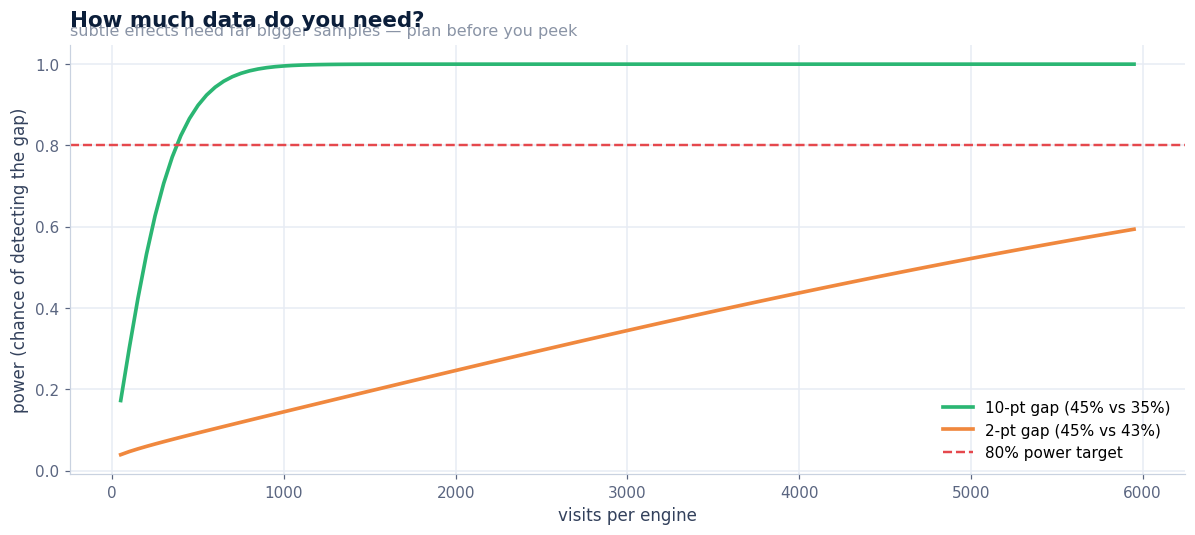

In [6]:
ns = np.arange(50, 6000, 50)
pow_big = [ni.power_two_proportions(0.45, 0.35, n) for n in ns]   # the real gap
pow_small = [ni.power_two_proportions(0.45, 0.43, n) for n in ns]  # a subtle gap

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ns, pow_big, color=ni.GREEN, lw=2.4, label="10-pt gap (45% vs 35%)")
ax.plot(ns, pow_small, color=ni.ORANGE, lw=2.4, label="2-pt gap (45% vs 43%)")
ax.axhline(0.8, color=ni.RED, ls="--", lw=1.6, label="80% power target")
ax.set_xlabel("visits per engine"); ax.set_ylabel("power (chance of detecting the gap)")
ax.legend()
ni.titlebox(ax, "How much data do you need?",
            "subtle effects need far bigger samples — plan before you peek")
fig.tight_layout(); ni.savefig(fig, "m4_power_curve"); plt.show()

## 6. Multiple comparisons: slice enough and you'll "find" anything

NI analysts slice dozens of verticals × engines × devices daily. If you run 40
*genuinely null* tests at α=0.05, you **expect ~2 false positives**. Here we run
many A/A tests across pretend "segments" — and watch false alarms appear. The
**Bonferroni** line shows the corrected bar.

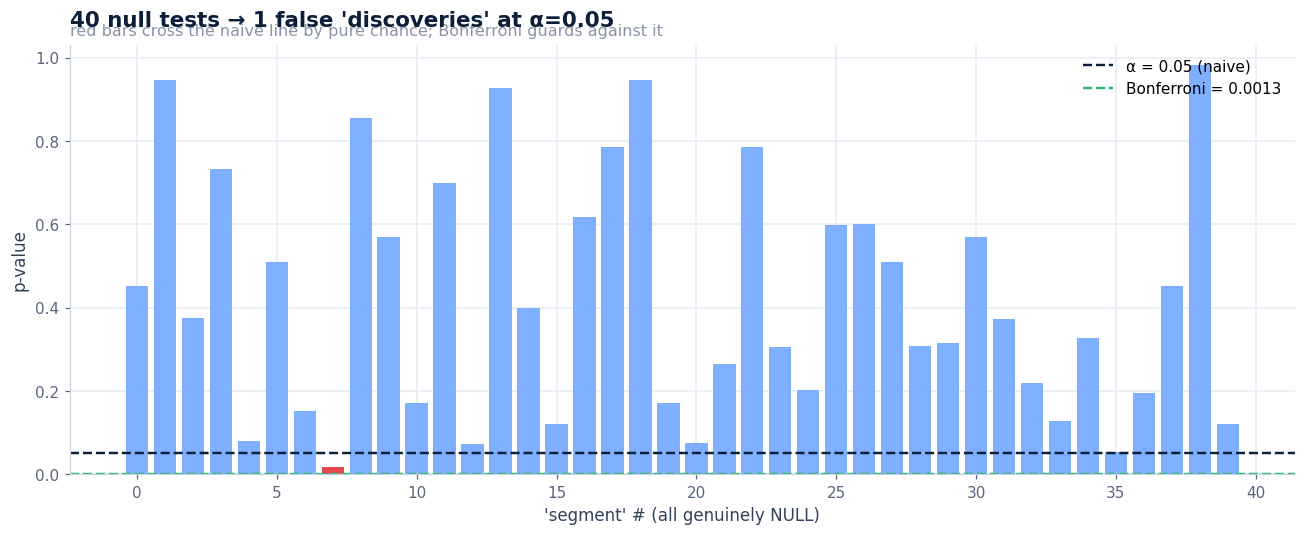

In [7]:
rng = np.random.default_rng(11)
m = 40
ps = []
base = visits["converted"].values
for _ in range(m):
    idx = rng.permutation(len(base)); h = 4000
    a, b = base[idx[:h]], base[idx[h:2*h]]
    ps.append(ni.two_proportion_ztest(a.sum(), h, b.sum(), h)["p_value"])
ps = np.array(ps)
false_pos = (ps < 0.05).sum()
bonf = 0.05 / m

fig, ax = plt.subplots(figsize=(12, 5))
colors = [ni.RED if p < 0.05 else ni.SKY for p in ps]
ax.bar(range(m), ps, color=colors)
ax.axhline(0.05, color=ni.NAVY, ls="--", lw=1.6, label="α = 0.05 (naive)")
ax.axhline(bonf, color=ni.GREEN, ls="--", lw=1.6, label=f"Bonferroni = {bonf:.4f}")
ax.set_xlabel("'segment' # (all genuinely NULL)"); ax.set_ylabel("p-value"); ax.legend()
ni.titlebox(ax, f"{m} null tests → {false_pos} false 'discoveries' at α=0.05",
            "red bars cross the naive line by pure chance; Bonferroni guards against it")
fig.tight_layout(); ni.savefig(fig, "m4_multiple_comparisons"); plt.show()

### ✅ Takeaway

> **Significant ≠ important, and significant ≠ true.**
> Check three things every time: (1) is n big enough that the *gap*, not the *size*,
> is driving the p-value? (2) is the test right for the data shape (rank/bootstrap
> for EPV)? (3) how many tests did I run — do I need a correction? The Google>Bing
> conversion gap survives all three. **It's real.**

**Next:** "real" isn't enough to move budget. *How big* is the effect, and *how
sure* are we? → *Module 5.*

**→ The skills that automate this:** `/significance-check` (cluster-aware) and `/relationship` (confound / Simpson's). On a thin real slice the CI includes 0 — a coin-flip — which sets up **Module 4 (borrow strength)**.